In [576]:
import numpy as np # type: ignore
import cv2 # type: ignore
import matplotlib.pyplot as plt # type: ignore

# Entrenamiento de una red de Hopfield con imágenes binarias

In [577]:
def show_two_images(image1,image2, title1 = "", title2 ="", size =(8,5)):    
    fig, axes = plt.subplots(1, 2, figsize= size) 

    axes[0].imshow(image1, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis('off')  

    axes[1].imshow(image2, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis('off')  

    plt.tight_layout()
    plt.show()



def show_three_images(image1,image2,image3, title1 = "", title2 ="", title3 ="", size = (8,5)):    
    fig, axes = plt.subplots(1, 3, figsize =size)  

    axes[0].imshow(image1, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis('off') 

    axes[1].imshow(image2, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis('off')  

    axes[2].imshow(image3, cmap='gray')
    axes[2].set_title(title3)
    axes[2].axis('off')  
   
    plt.tight_layout()
    plt.show()


def show_images_side_by_side(image1, image2, image3, image4, image5, image6, titles=None):
    images = [image1, image2, image3, image4, image5, image6]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes = axes.flatten()

    for i, image in enumerate(images):
        axes[i].imshow(image, cmap='gray')  
        if titles is not None and len(titles) == 6:
            axes[i].set_title(titles[i])  
        axes[i].axis('off')  
    
    plt.tight_layout() 
    plt.show()

Cargo las imagenes y pruebo llevarlas a todas a una misma resolución

In [578]:
#Imagenes de 2500 pixeles (50x50)
pandaOriginal = cv2.imread("panda.bmp", cv2.IMREAD_GRAYSCALE)
vOriginal = cv2.imread("v.bmp", cv2.IMREAD_GRAYSCALE)
perroOriginal = cv2.imread("perro.bmp", cv2.IMREAD_GRAYSCALE)

#Imagenes de 2925 pixeles (65x45)
quijoteOriginal = cv2.imread("quijote.bmp", cv2.IMREAD_GRAYSCALE)
palomaOriginal = cv2.imread("paloma.bmp", cv2.IMREAD_GRAYSCALE)
toreroOriginal = cv2.imread("torero.bmp", cv2.IMREAD_GRAYSCALE)


Para entrenar a la red neuronal o evaluarla, necesito a las imagenes en forma de vector y en el caso del entrenamiento cada imagen va a ser la columna de una matriz

In [579]:
def load_image_to_pattern(image):
    _, binary_image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY) # Convertir la imagen binaria a valores 0 y 1
    patron = (binary_image / 255.0) * 2 - 1 # Convertir la imagen binaria a valores -1 y 1
    return patron.flatten() # Me devuelve un arreglo unidimensional

In [580]:
def recover_image(imageVectorized, originalShape = (50,50)):
    # Reconvertir el estado 1D a la forma original de la imagen
    recoveredImage = imageVectorized.reshape(originalShape)
    
    # Convertir de valores -1, 1 a 0, 255 para poder visualizar como imagen
    recoveredImage = (recoveredImage + 1) / 2 * 255
    return recoveredImage.astype(np.uint8)

# Ejercicio 1
Entrene una red de Hopfield '82 con las imágenes binarias disponibles en el campus.

1. **Verifique** si la red aprendió las imágenes enseñadas.
2. **Evalúe la evolución** de la red al presentarle versiones alteradas de las imágenes aprendidas:
   - Agregado de ruido,
   - Elementos borrados o agregados.
3. **Evalúe la existencia** de estados espurios en la red:
   - Patrones inversos,
   - Combinaciones de un número impar de patrones.
   
   *(Ver "Spurious States", en la sección 2.2, Hertz, Krogh & Palmer, pág. 24)*.
   
4. **Realice un entrenamiento** con las 6 imágenes disponibles. ¿Es capaz la red de aprender todas las imágenes? Explique.

Se utilizara la siguiente implementación de la Red Hopfield

In [581]:
class HopfieldNetwork:
    def __init__(self, num_neurons):
        self.num_neurons = num_neurons
        self.weights = np.zeros((num_neurons, num_neurons))


    def train(self, patterns):
        self.weights += patterns @ patterns.T
        np.fill_diagonal(self.weights, 0)
    

    def evaluate_asynchronous(self, inicialInput):
        state = inicialInput
        previousState= np.zeros((self.num_neurons, 1))
        cicles = 0
        while not (np.array_equal(state, previousState)):
            previousState = state
            indices = np.random.permutation(self.num_neurons)
            for i in indices :
                sum = np.dot(self.weights[i,:], state)
                state[i] = np.where(sum > 0,1,-1)               
            cicles += 1 
        return state,cicles
    
    
    def evaluate_synchronous(self, pattern):
        sum_values = self.weights @ pattern
        return np.where(sum_values > 0,1,-1) 
    

### Red Hopfield para tamaño 50x50 : *Red1*


La red Hopfield **red1** trabajara solo con las imagenes de tamaño 50x50:  *panda.bmp*, *perro.bmp* y *v.bmp*

In [582]:
patterns1 = []
patterns1.append(load_image_to_pattern(pandaOriginal))
patterns1.append(load_image_to_pattern(vOriginal))
patterns1.append(load_image_to_pattern(perroOriginal))
patterns1 = np.array(patterns1).T

red1 = HopfieldNetwork(2500)
red1.train(patterns1)

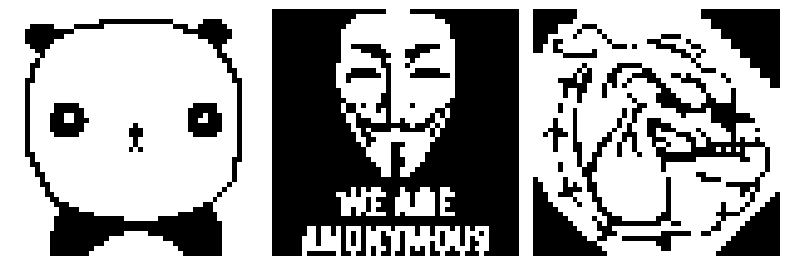

In [583]:
show_three_images(pandaOriginal, vOriginal, perroOriginal)

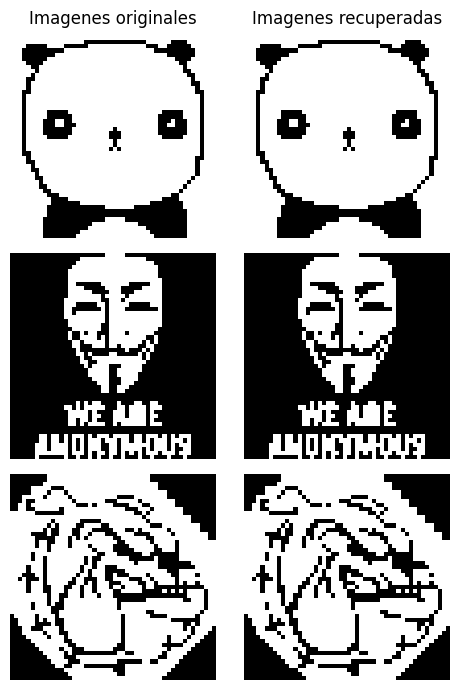

In [584]:
recovered = []
for i in [pandaOriginal, vOriginal, perroOriginal]:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  

original_images = [pandaOriginal, vOriginal, perroOriginal]



fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Muestro imágenes originales (columna izquierda)
    axes[i, 0].imshow(original_images[i], cmap='gray')
    axes[i, 0].axis('off')  # Ocultar los ejes
    axes[0, 0].set_title(f"Imagenes originales")
    
    # Muestro imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  # Ocultar los ejes
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

Se evaluara la red con imagenes recortadas para ver si logra recuperarlas

In [585]:
import random
def crop_image(image, crop_percentage):

    # Determinar el tamaño del recorte
    height, width = image.shape[:2]
    crop_height = int(height * crop_percentage)
    crop_width = int(width * crop_percentage)

    # Elegir de forma aleatoria si recortar horizontal o verticalmente
    if random.choice(['horizontal', 'vertical']) == 'horizontal':
        # Recorte horizontal
        start_row = random.randint(0, height - crop_height)
        image[start_row:start_row + crop_height, :] = 255  # O cualquier valor que desees
    else:
        # Recorte vertical
        start_col = random.randint(0, width - crop_width)
        image[:, start_col:start_col + crop_width] = 255  # O cualquier valor que desees

    return image



Pruebo recuperar las imagenes cuando las evaluo con el set original con recortes

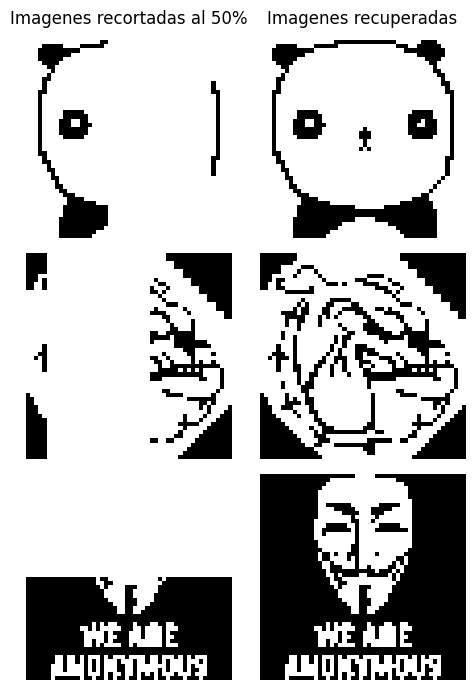

In [586]:
# Suponiendo que pandaOriginal, perroOriginal y vOriginal son tus imágenes originales
pandaRecortado = crop_image(pandaOriginal.copy(), crop_percentage=0.5)  # 30% de recorte
perroRecortado = crop_image(perroOriginal.copy(), crop_percentage=0.5)
vRecortado = crop_image(vOriginal.copy(), crop_percentage=0.5)

cut_images = [pandaRecortado, perroRecortado, vRecortado]

# Suponiendo que tienes una red neuronal llamada red1 para evaluar las imágenes
recovered_images = []
for image in cut_images:
    example, cycles = red1.evaluate_asynchronous(load_image_to_pattern(image))
    recovered_images.append(recover_image(example, (50, 50)))

fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Mostrar imágenes originales (columna izquierda)
    axes[i, 0].imshow(cut_images[i], cmap='gray')
    axes[i, 0].axis('off')  # Ocultar los ejes
    axes[0, 0].set_title(f"Imagenes recortadas al 50%")
    
    # Mostrar imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered_images[i], cmap='gray')
    axes[i, 1].axis('off')  # Ocultar los ejes
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

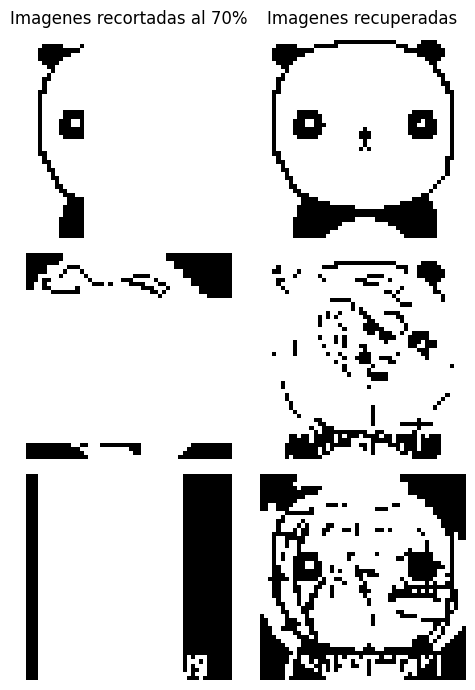

In [587]:
# Suponiendo que pandaOriginal, perroOriginal y vOriginal son tus imágenes originales
pandaRecortado = crop_image(pandaOriginal.copy(), crop_percentage=0.7)  # 70% de recorte
perroRecortado = crop_image(perroOriginal.copy(), crop_percentage=0.7)
vRecortado = crop_image(vOriginal.copy(), crop_percentage=0.7)

cut_images = [pandaRecortado, perroRecortado, vRecortado]

# Suponiendo que tienes una red neuronal llamada red1 para evaluar las imágenes
recovered_images = []
for image in cut_images:
    example, cycles = red1.evaluate_asynchronous(load_image_to_pattern(image))
    recovered_images.append(recover_image(example, (50, 50)))

fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Mostrar imágenes originales (columna izquierda)
    axes[i, 0].imshow(cut_images[i], cmap='gray')
    axes[i, 0].axis('off')  # Ocultar los ejes
    axes[0, 0].set_title(f"Imagenes recortadas al 70%")
    
    # Mostrar imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered_images[i], cmap='gray')
    axes[i, 1].axis('off')  # Ocultar los ejes
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

Pruebo recuperar las imagenes cuando las evaluo con el set original con recortes

In [588]:
import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt

def get_noisy_image(input_image, porcentaje, color_borrar=255):
    output_image = input_image.copy()

    # Obtengo dimensiones de la imagen
    height, width = output_image.shape
    total_pixeles = width * height

    # Calculo cuántos píxeles debemos borrar
    pixeles_a_borrar = int(total_pixeles * (porcentaje / 100))

    # Creo una lista de todas las coordenadas de la imagen
    coordenadas = [(x, y) for x in range(width) for y in range(height)]

    # Selecciono al azar las coordenadas a borrar
    coordenadas_borrar = random.sample(coordenadas, pixeles_a_borrar)

    # Borro los píxeles (cambiarlos al color especificado)
    for coord in coordenadas_borrar:
        output_image[coord[1], coord[0]] = color_borrar 

    return output_image 


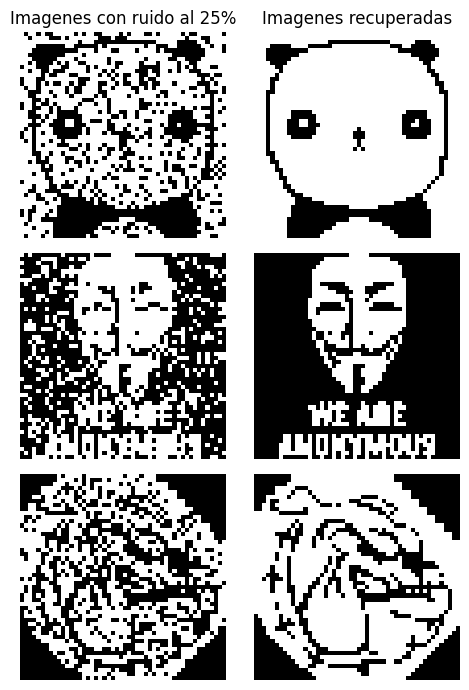

In [589]:
# Llamar a la función para agregar ruido
pandaRuidoso25 = get_noisy_image(pandaOriginal, 25, 0)  
vRuidoso25 = get_noisy_image(vOriginal, 25, 255)
perroRuidoso25 = get_noisy_image(perroOriginal, 25, 0)

noisy_images = [pandaRuidoso25, vRuidoso25, perroRuidoso25]

recovered = []
for i in noisy_images:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  
    #show_two_images(i, Recovered, "Panda - Original", "Panda - resultado")
fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Mostrar imágenes originales (columna izquierda)
    axes[i, 0].imshow(noisy_images[i], cmap='gray')
    axes[i, 0].axis('off')  # Ocultar los ejes
    axes[0, 0].set_title(f"Imagenes con ruido al 25%")
    
    # Mostrar imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  # Ocultar los ejes
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

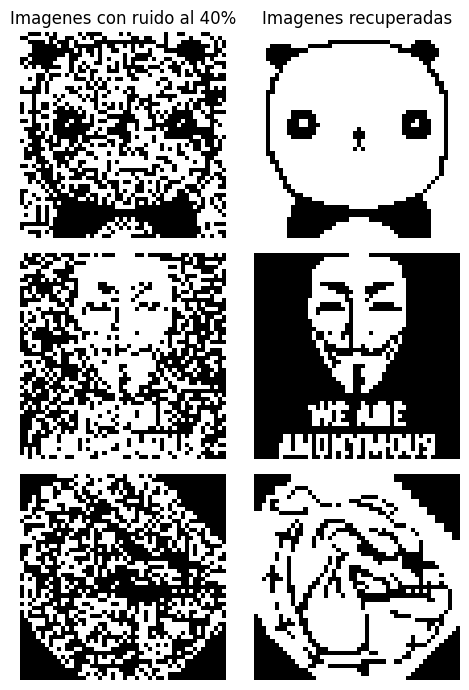

In [590]:
# Llamar a la función para agregar ruido
pandaRuidoso40 = get_noisy_image(pandaOriginal, 40, 0)  # Por ejemplo, 30% de ruido
vRuidoso40 = get_noisy_image(vOriginal, 40, 255)
perroRuidoso40 = get_noisy_image(perroOriginal, 40, 0)

noisy_images = [pandaRuidoso40, vRuidoso40, perroRuidoso40]

recovered = []
for i in noisy_images:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  
    #show_two_images(i, Recovered, "Panda - Original", "Panda - resultado")
fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Mostrar imágenes originales (columna izquierda)
    axes[i, 0].imshow(noisy_images[i], cmap='gray')
    axes[i, 0].axis('off')  # Ocultar los ejes
    axes[0, 0].set_title(f"Imagenes con ruido al 40%")
    
    # Mostrar imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  # Ocultar los ejes
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

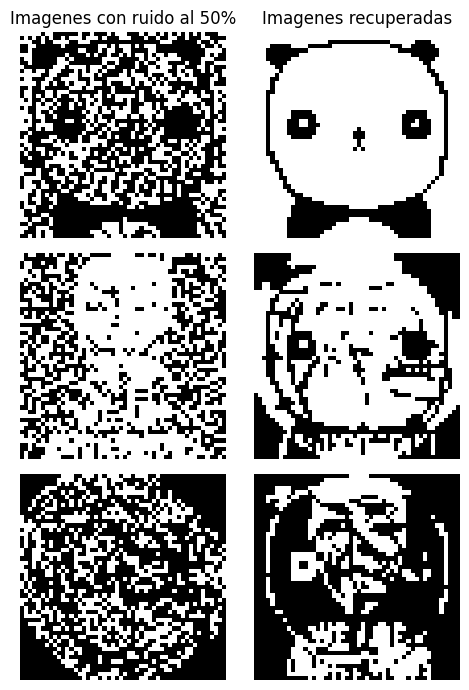

In [591]:
# Llamar a la función para agregar ruido
pandaRuidoso25 = get_noisy_image(pandaOriginal, 50, 0)  # Por ejemplo, 30% de ruido
vRuidoso25 = get_noisy_image(vOriginal, 50, 255)
perroRuidoso25 = get_noisy_image(perroOriginal, 50, 0)

noisy_images = [pandaRuidoso25, vRuidoso25, perroRuidoso25]

recovered = []
for i in noisy_images:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  
    #show_two_images(i, Recovered, "Panda - Original", "Panda - resultado")
fig, axes = plt.subplots(3, 2, figsize=(5, 7))  # 3 filas y 2 columnas
for i in range(3):
    # Mostrar imágenes originales (columna izquierda)
    axes[i, 0].imshow(noisy_images[i], cmap='gray')
    axes[i, 0].axis('off')  # Ocultar los ejes
    axes[0, 0].set_title(f"Imagenes con ruido al 50%")
    
    # Mostrar imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  # Ocultar los ejes
    axes[0, 1].set_title(f"Imagenes recuperadas")

plt.tight_layout()
plt.show()

Busco estados espureos, es decir combinaciones impares de patrones que pudo haber aprendido la red

In [631]:
espureo1 = -1*load_image_to_pattern(pandaOriginal.copy())
espureo2 = -1*load_image_to_pattern(vOriginal.copy())
espureo3 = -1*load_image_to_pattern(perroOriginal.copy())
espureo4 = np.where( load_image_to_pattern(pandaOriginal.copy()) + load_image_to_pattern(vOriginal.copy()) + load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo5 = np.where( -load_image_to_pattern(pandaOriginal.copy()) + load_image_to_pattern(vOriginal.copy()) + load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo6 = np.where( -load_image_to_pattern(pandaOriginal.copy()) - load_image_to_pattern(vOriginal.copy()) + load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo7 = np.where( -load_image_to_pattern(pandaOriginal.copy()) - load_image_to_pattern(vOriginal.copy()) - load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo8 = np.where( load_image_to_pattern(pandaOriginal.copy()) - load_image_to_pattern(vOriginal.copy()) - load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo9 = np.where( load_image_to_pattern(pandaOriginal.copy()) + load_image_to_pattern(vOriginal.copy()) - load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)

espureo10 = np.where( -load_image_to_pattern(pandaOriginal.copy()) + load_image_to_pattern(vOriginal.copy()) - load_image_to_pattern(perroOriginal.copy())  > 0,1,-1)
espureo11 = -1 * espureo8



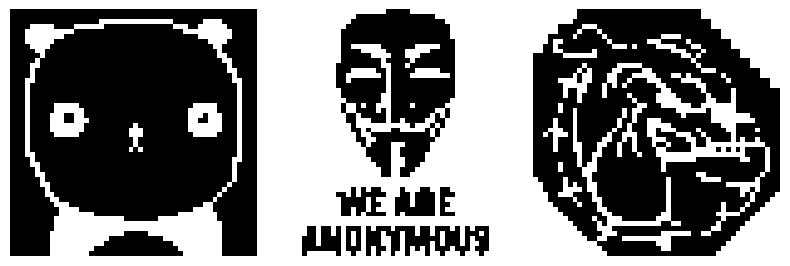

In [632]:
fig, axes = plt.subplots(1, 3, figsize=(8, 8))  # 2 filas y 3 columnas

# Combinar imágenes originales con ruido y recuperadas en una sola lista
combined_images = [recover_image(espureo1), recover_image(espureo2), recover_image(espureo3)] # Lista combinada

for i in range(3):
    # Mostrar imágenes con ruido (primer fila)
    axes[i].imshow(combined_images[i], cmap='gray')
    axes[i].axis('off')  # Ocultar los ejes

plt.tight_layout()
plt.show()

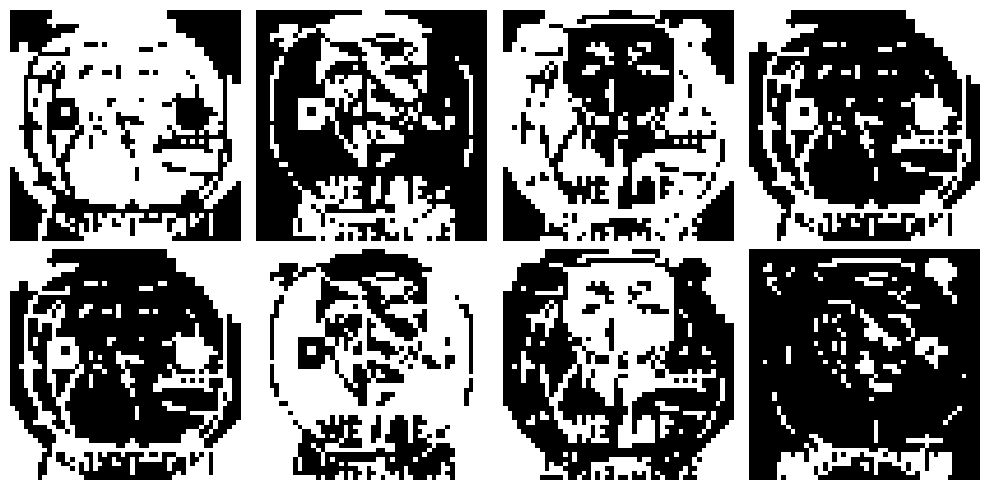

In [633]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))  # 2 filas y 3 columnas
# Combinar imágenes originales con ruido y recuperadas en una sola lista
combined_images = [recover_image(espureo4), recover_image(espureo5), recover_image(espureo6), recover_image(espureo7), 
                   recover_image(espureo8), recover_image(espureo9), recover_image(espureo10), recover_image(espureo11)] # Lista combinada

for i in range(4):
    # Mostrar imágenes con ruido (primer fila)
    axes[0, i].imshow(combined_images[i], cmap='gray')
    axes[0, i].axis('off')  # Ocultar los ejes

    # Mostrar imágenes recuperadas (segunda fila)
    axes[1, i].imshow(combined_images[i + 3], cmap='gray')
    axes[1, i].axis('off')  # Ocultar los ejes


plt.tight_layout()
plt.show()

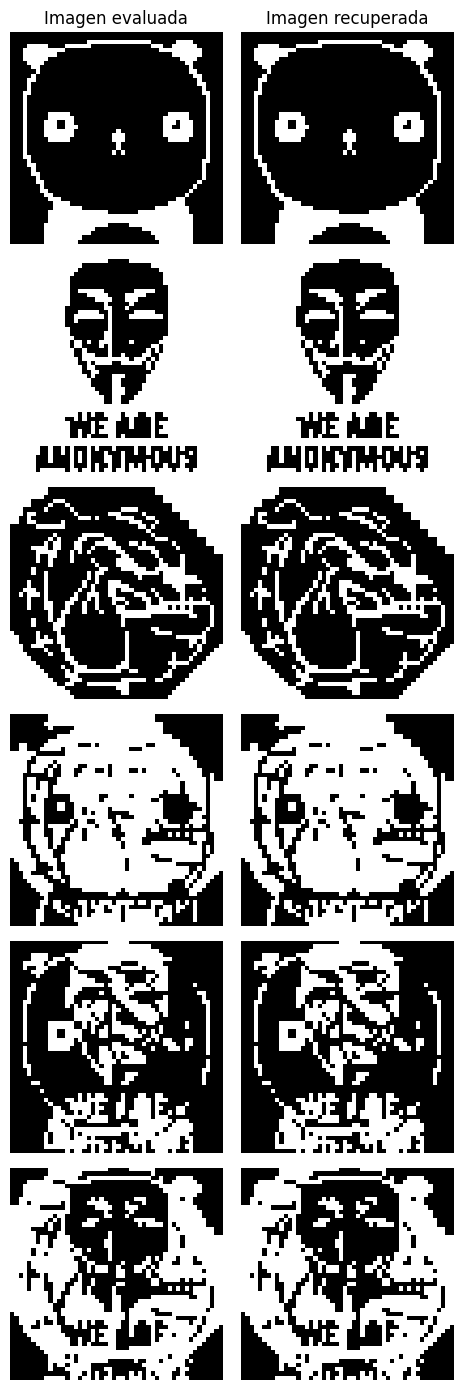

In [639]:

espurio_images = [recover_image(espureo1), recover_image(espureo2), recover_image(espureo3),
                  recover_image(espureo4), recover_image(espureo5), recover_image(espureo6), recover_image(espureo7), 
                  recover_image(espureo8), recover_image(espureo9), recover_image(espureo10), recover_image(espureo11)]

recovered = []
for i in espurio_images:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  


fig, axes = plt.subplots(6, 2, figsize=(5, 14))  # 3 filas y 2 columnas
for i in range(6):
    # Mostrar imágenes originales (columna izquierda)
    axes[i, 0].imshow(espurio_images[i], cmap='gray')
    axes[i, 0].axis('off')  # Ocultar los ejes
    axes[0, 0].set_title(f"Imagen evaluada")
    
    # Mostrar imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  # Ocultar los ejes
    axes[0, 1].set_title(f"Imagen recuperada")

plt.tight_layout()
plt.show()

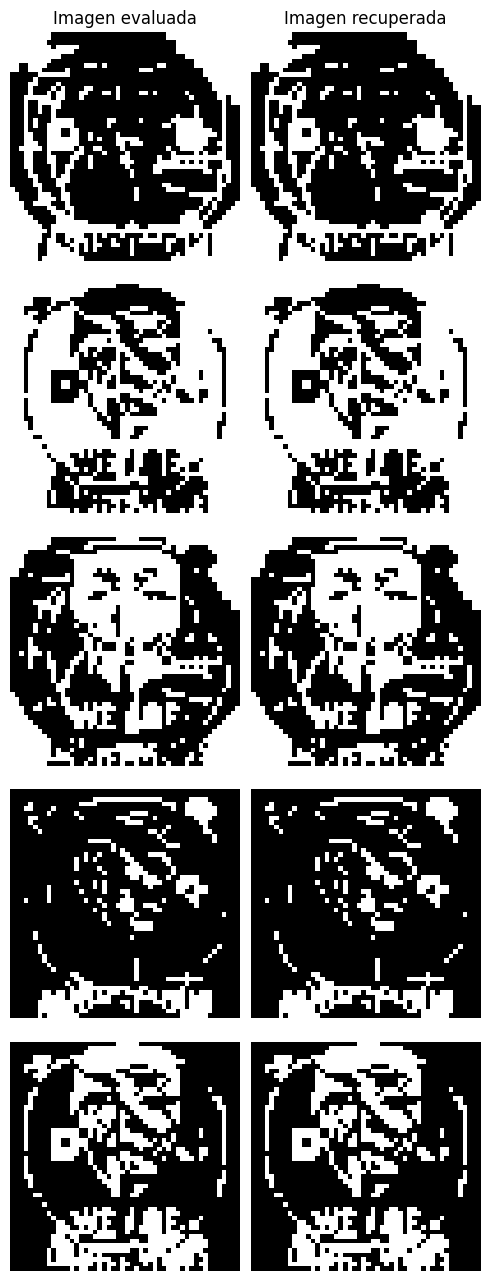

In [638]:
espurio_images = [recover_image(espureo7), recover_image(espureo8), recover_image(espureo9), recover_image(espureo10), recover_image(espureo11)]

recovered = []
for i in espurio_images:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    recovered.append(recover_image(example, (50,50)))  


fig, axes = plt.subplots(5, 2, figsize=(5, 13))  # 3 filas y 2 columnas
for i in range(5):
    # Mostrar imágenes originales (columna izquierda)
    axes[i, 0].imshow(espurio_images[i], cmap='gray')
    axes[i, 0].axis('off')  # Ocultar los ejes
    axes[0, 0].set_title(f"Imagen evaluada")
    
    # Mostrar imágenes recuperadas (columna derecha)
    axes[i, 1].imshow(recovered[i], cmap='gray')
    axes[i, 1].axis('off')  # Ocultar los ejes
    axes[0, 1].set_title(f"Imagen recuperada")

plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Pruebo red neuronal para el caso de completar los pixeles faltantes de las imagenes

In [595]:
pandaFullfil = np.hstack([pandaOriginal.copy(),np.zeros((50, 10))])
vFullfil = np.hstack([vOriginal.copy(),np.zeros((50, 10))])
perroFullfil = np.hstack([perroOriginal.copy(),np.zeros((50, 10))])
quijoteFullfil = np.vstack([quijoteOriginal.copy(),np.zeros((5, 60))])
palomaFullfil = np.vstack([palomaOriginal.copy(),np.zeros((5, 60))])
toreroFullfil = np.vstack([toreroOriginal.copy(),np.zeros((5, 60))])

In [596]:

patterns2 = []
patterns2.append(load_image_to_pattern(pandaFullfil))
patterns2.append(load_image_to_pattern(vFullfil))
patterns2.append(load_image_to_pattern(perroFullfil))
patterns2.append(load_image_to_pattern(palomaFullfil))
patterns2.append(load_image_to_pattern(toreroFullfil))
patterns2.append(load_image_to_pattern(quijoteFullfil))
patterns2 = np.array(patterns2).T

red2 = HopfieldNetwork(3000)
red2.train(patterns2)


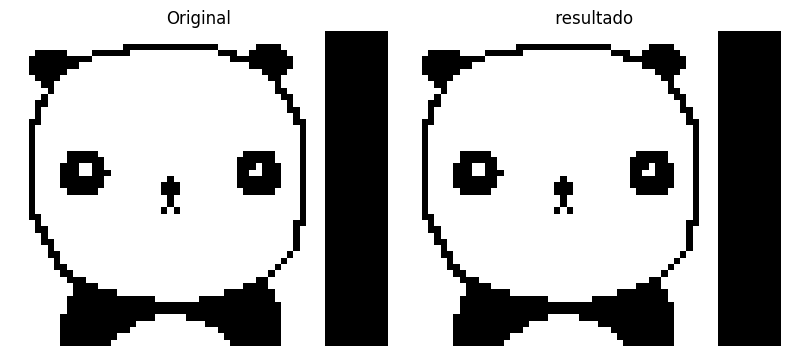

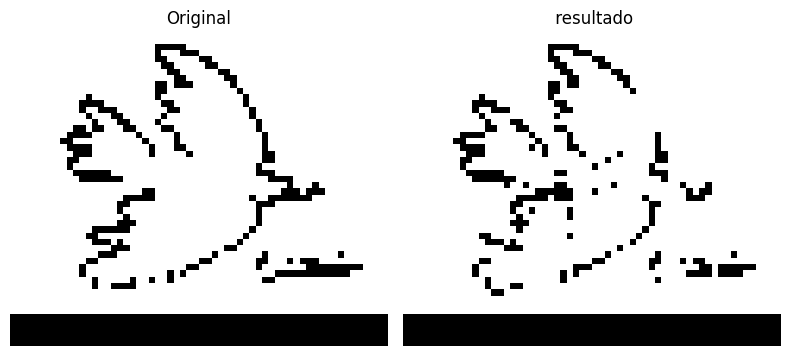

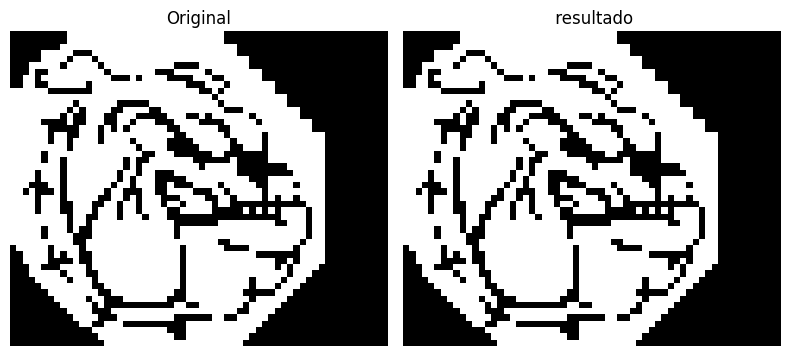

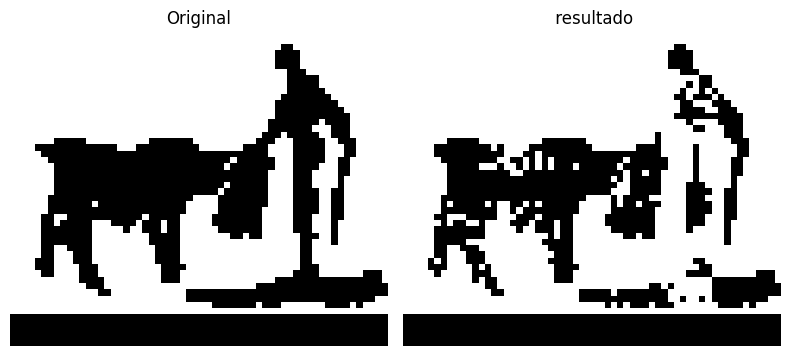

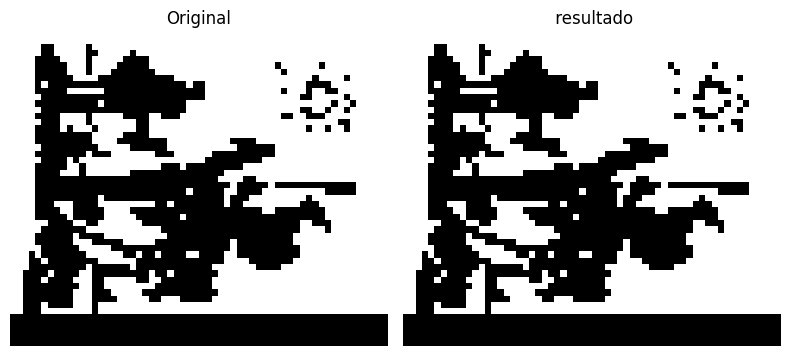

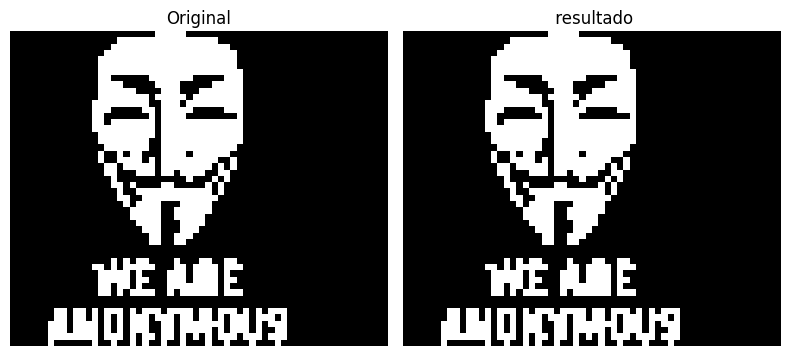

In [597]:
for i in [pandaFullfil, palomaFullfil, perroFullfil, toreroFullfil, quijoteFullfil, vFullfil]:
    example,_ = red2.evaluate_asynchronous(load_image_to_pattern(i))
    Recovered = recover_image(example, (50,60))
    show_two_images(i, Recovered, "Original", " resultado")

Ahora pruebo una red neuronal con imagenes escaladas

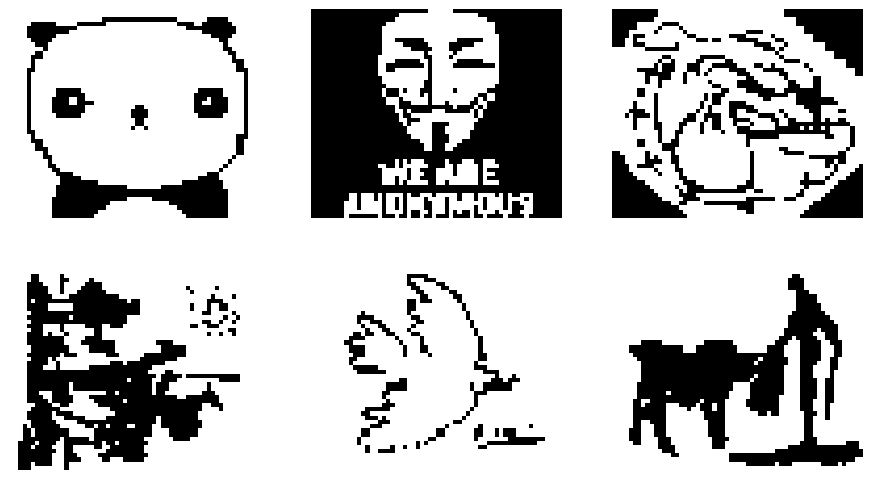

In [664]:
scale = (60,50)
pandaScaled = cv2.resize(pandaOriginal, scale, interpolation=cv2.INTER_NEAREST)
vScaled = cv2.resize(vOriginal, scale, interpolation=cv2.INTER_NEAREST)
perroScaled = cv2.resize(perroOriginal, scale, interpolation=cv2.INTER_NEAREST)
quijoteScaled = cv2.resize(quijoteOriginal, scale, interpolation=cv2.INTER_NEAREST)
palomaScaled = cv2.resize(palomaOriginal, scale, interpolation=cv2.INTER_NEAREST)
toreroScaled = cv2.resize(toreroOriginal, scale, interpolation=cv2.INTER_NEAREST)

scaled_images = [pandaScaled, vScaled, perroScaled, quijoteScaled, palomaScaled, toreroScaled]
fig, axes = plt.subplots(2, 3, figsize=(11, 6))  # 3 filas y 2 columnas
for i in range(3):
    # Mostrar imágenes originales (columna izquierda)
    axes[0, i].imshow(scaled_images[i], cmap='gray')
    axes[0, i].axis('off')  # Ocultar los ejes

    
    # Mostrar imágenes recuperadas (columna derecha)
    axes[1, i].imshow(scaled_images[i+3], cmap='gray')
    axes[1, i].axis('off')  # Ocultar los ejes


In [601]:
patterns3 = []
patterns3.append(load_image_to_pattern(pandaScaled))
patterns3.append(load_image_to_pattern(vScaled))
patterns3.append(load_image_to_pattern(perroScaled))
patterns3.append(load_image_to_pattern(palomaScaled))
patterns3.append(load_image_to_pattern(toreroScaled))
patterns3.append(load_image_to_pattern(quijoteScaled))
patterns3 = np.array(patterns3).T

red3 = HopfieldNetwork(3000)
red3.train(patterns3)

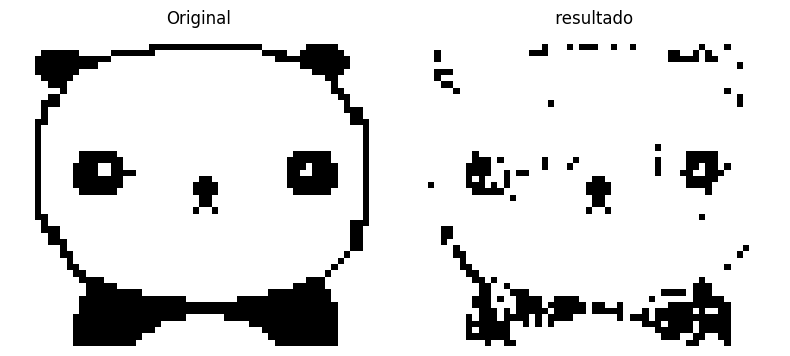

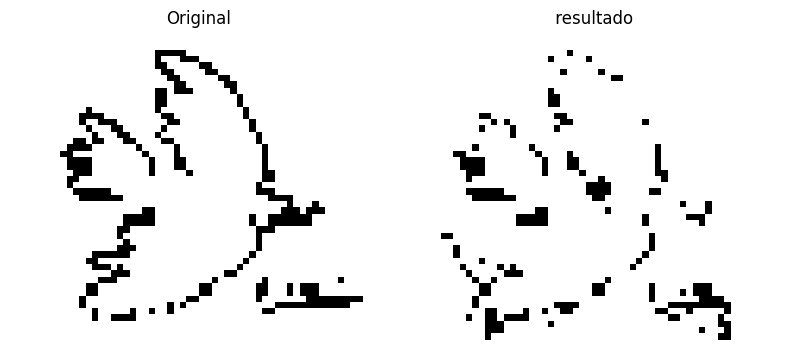

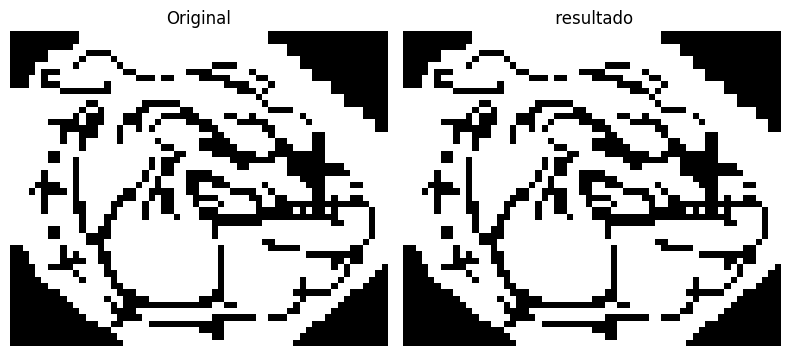

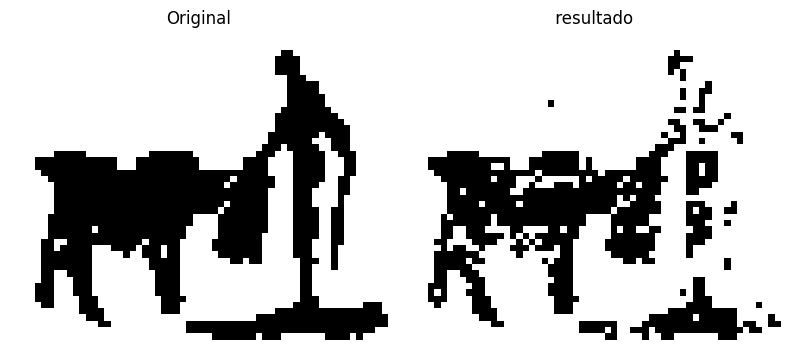

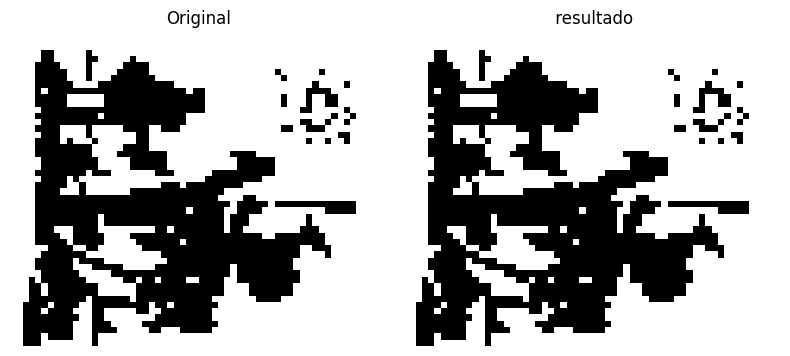

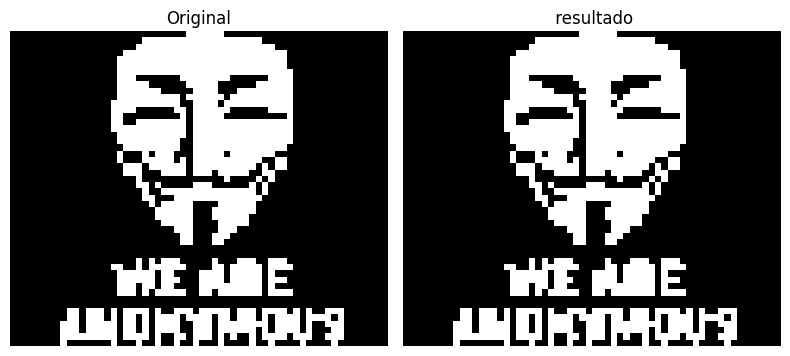

In [602]:
for i in [pandaScaled, palomaScaled, perroScaled, toreroScaled, quijoteScaled, vScaled]:
    example,_ = red3.evaluate_asynchronous(load_image_to_pattern(i))
    Recovered = recover_image(example, (50,60))
    show_two_images(i, Recovered, "Original", " resultado")

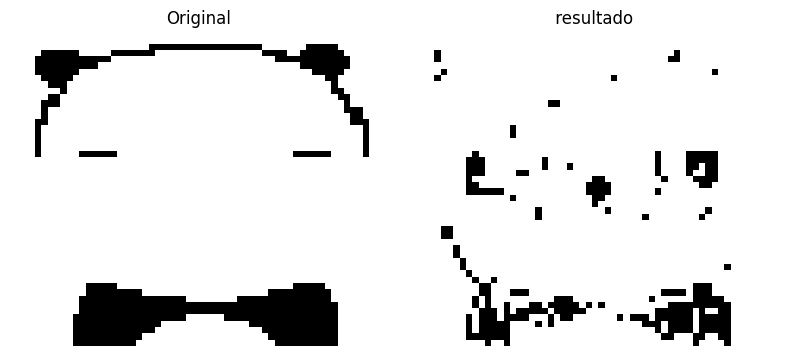

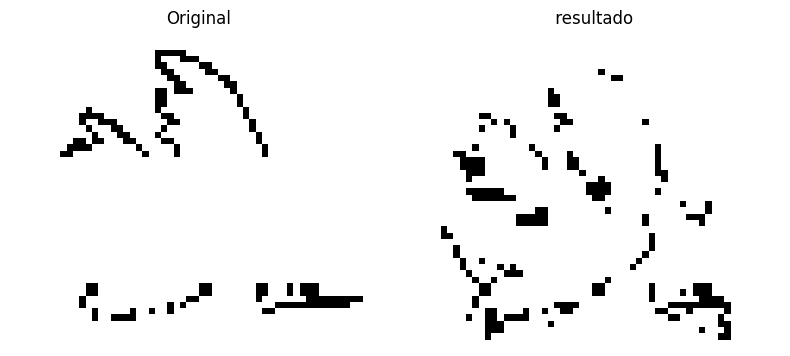

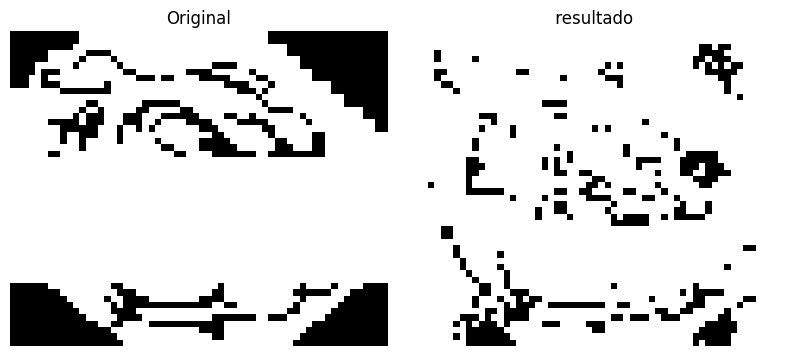

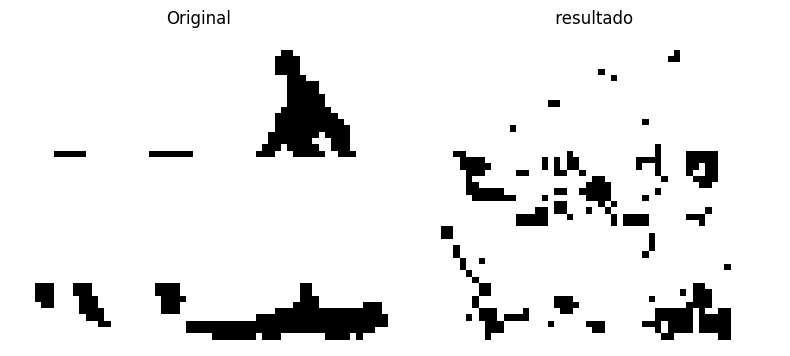

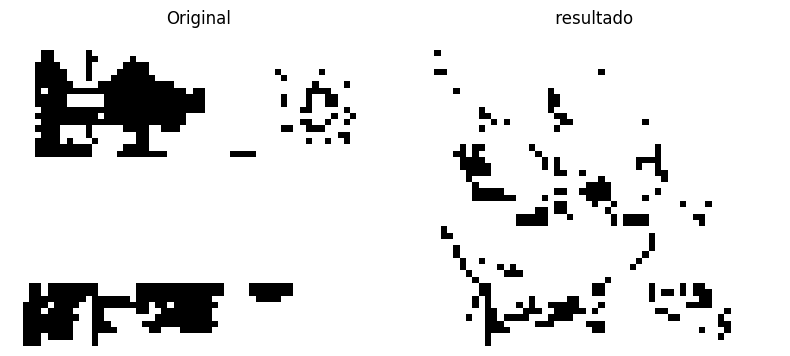

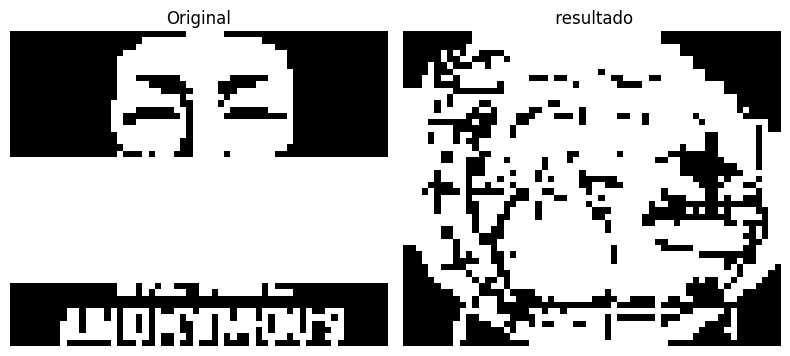

In [603]:
for i in [pandaScaled, palomaScaled, perroScaled, toreroScaled, quijoteScaled, vScaled]:
    aux = i.copy()
    aux[20:40, :] = 255
    example,_ = red3.evaluate_asynchronous(load_image_to_pattern(aux))
    Recovered = recover_image(example, (50,60))
    show_two_images(aux, Recovered, "Original", " resultado")

EJERCICIO 2

In [667]:
def capacity_by_error(P_error, N):
    hopfield_net = HopfieldNetwork(N)
    patterns_accumulated = np.empty((N, 0)) 
    error_neurons = 0
    
    while error_neurons < P_error:
        new_pattern = np.random.choice([-1, 1], size=(N,)).reshape(N, 1)  # Genera una columna
        hopfield_net.train(new_pattern)  # Entrenamos con el patrón como vector unidimensional
        patterns_accumulated = np.hstack((patterns_accumulated, new_pattern))
        evaluated_patterns = hopfield_net.evaluate_synchronous(patterns_accumulated)
        error_neurons = np.count_nonzero(evaluated_patterns- patterns_accumulated) / (patterns_accumulated.shape[1]*N)
        
    capacity = (patterns_accumulated.shape[1]-1)/N
    return capacity



In [669]:
capacities = []
aux = 0
for i in [0.0010,0.0036,0.0100,0.0500,0.1000]:
    capacities.append(capacity_by_error(i, 500))
    print(f"Perror = {i}      Pmax/N ={capacities[aux]}\n")
    aux = aux + 1

Perror = 0.001      Pmax/N =0.108

Perror = 0.0036      Pmax/N =0.134

Perror = 0.01      Pmax/N =0.182

Perror = 0.05      Pmax/N =0.366

Perror = 0.1      Pmax/N =0.614



In [673]:
capacities = []
aux = 0
for i in [0.0010,0.0036,0.0100,0.0500,0.1000]:
    capacities.append(capacity_by_error(i, 1500))
    print(f"Perror = {i}      Pmax/N ={capacities[aux]}\n")
    aux = aux + 1


Perror = 0.001      Pmax/N =0.10466666666666667

Perror = 0.0036      Pmax/N =0.13733333333333334

Perror = 0.01      Pmax/N =0.18466666666666667

Perror = 0.05      Pmax/N =0.36866666666666664

Perror = 0.1      Pmax/N =0.6093333333333333



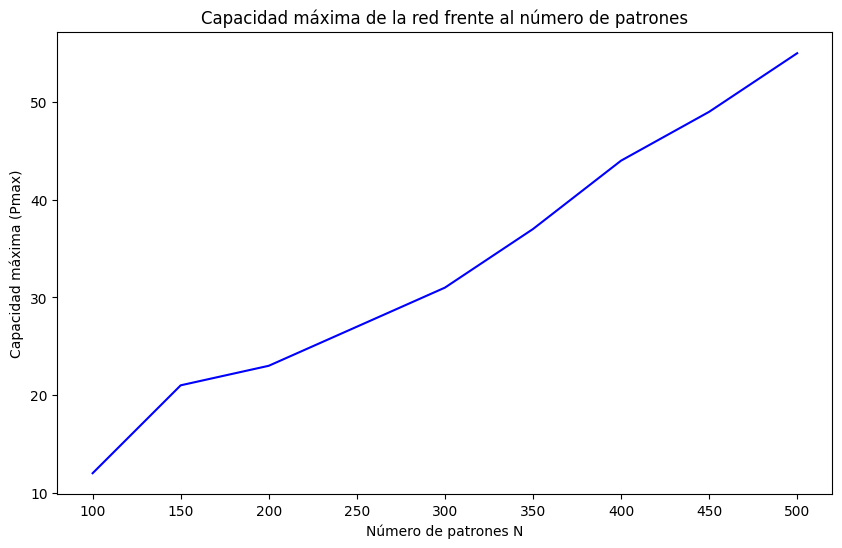

In [674]:
N = 500
Perror= 0.001
Pmax = []
for i in range(100,N+1,50):
    Pmax.append(capacity_by_error(Perror, i)*i)

x = np.arange(100, N + 1,50)
# Crear la gráfica
plt.figure(figsize=(10, 6))  # Tamaño de la figura (opcional)
plt.plot(x, Pmax, linestyle='-', color='b')  # Línea con marcadores
plt.xlabel('Número de patrones N')
plt.ylabel('Capacidad máxima (Pmax)')
plt.title('Capacidad máxima de la red frente al número de patrones')
plt.show()

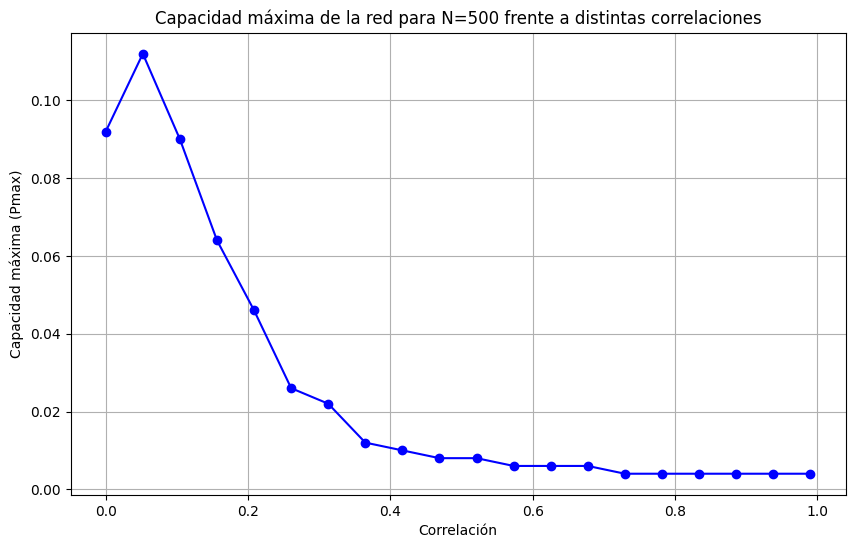

In [607]:
def generate_correlated_patterns_bernoulli(base_pattern, correlation, num_patterns):
    """
    Genera patrones correlacionados utilizando una distribución Bernoulli controlada por un vector de arranque.
    
    Parameters:
    - base_pattern: Patrón base a partir del cual generar los nuevos patrones.
    - correlation: Grado de correlación deseada (entre 0 y 1).
    - num_patterns: Número de patrones correlacionados a generar.
    
    Returns:
    - correlated_patterns: Matriz con los patrones correlacionados.
    """
    N = len(base_pattern)
    correlated_patterns = np.empty((N, num_patterns))
    
    for i in range(num_patterns):
        for j in range(N):
            prob = (1 + correlation) / 2 if base_pattern[j] == 1 else (1 - correlation) / 2
            correlated_patterns[j, i] = 1 if np.random.rand() < prob else -1
    
    return correlated_patterns

def capacity_by_error_correlated(P_error, N, correlation, max_iter=1000):
    """
    Calcula la capacidad máxima de la red de Hopfield para patrones correlacionados.
    
    Parameters:
    - P_error: Error máximo permitido.
    - N: Número de neuronas.
    - correlation: Correlación entre los patrones.
    - max_iter: Número máximo de iteraciones permitidas.
    
    Returns:
    - Capacidad máxima estimada.
    """
    hopfield_net = HopfieldNetwork(N)
    patterns_accumulated = np.empty((N, 0))
    error_neurons = 0
    iteration = 0
    
    # Generar patrón base aleatorio
    base_pattern = generate_random_pattern(N)
    
    while error_neurons < P_error and iteration < max_iter:
        # Generamos un nuevo patrón correlacionado con la distribución Bernoulli
        correlated_pattern = generate_correlated_patterns_bernoulli(base_pattern, correlation, 1).reshape(N, 1)
        
        hopfield_net.train(correlated_pattern)
        patterns_accumulated = np.hstack((patterns_accumulated, correlated_pattern))
        
        evaluated_patterns = hopfield_net.evaluate_synchronous(patterns_accumulated)
        
        differences = evaluated_patterns - patterns_accumulated
        error_neurons = np.count_nonzero(differences) / (patterns_accumulated.shape[1] * N)
        
        iteration += 1
       
    capacity = (patterns_accumulated.shape[1] - 1) / N
    return capacity

def plot_capacity_by_correlation(N, P_error, correlations, max_iter=1000):
    Pmax_values = []

    for corr in correlations:
        capacities = capacity_by_error_correlated(P_error, N, corr, max_iter)
        Pmax_values.append(capacities)

    # Graficar Pmax en función de las correlaciones
    plt.figure(figsize=(10, 6))
    plt.plot(correlations, Pmax_values, marker='o', linestyle='-', color='b')
    plt.xlabel('Correlación')
    plt.ylabel('Capacidad máxima (Pmax)')
    plt.title(f'Capacidad máxima de la red para N={N} frente a distintas correlaciones')
    plt.grid(True)
    plt.show()



# Parámetros
N = 500
P_error = 0.001
correlations = np.linspace(0, 0.99, 20)  # Correlaciones desde 0 hasta 1 (0, 0.1, 0.2, ..., 1)

# Llamar a la función de graficado
plot_capacity_by_correlation(N, P_error, correlations, max_iter=200)

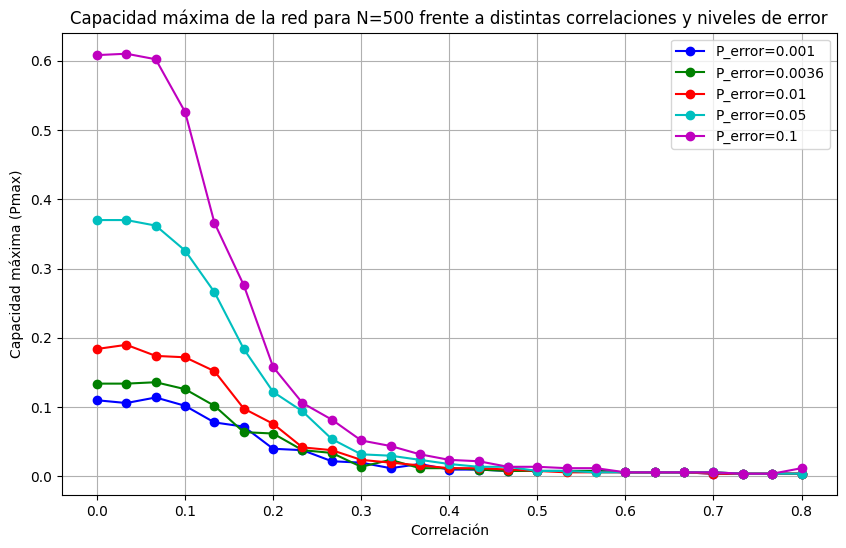

In [608]:
def plot_capacity_by_correlation(N, P_errors, correlations, max_iter=1000):
    """
    Genera un gráfico de la capacidad máxima de la red (Pmax) para distintos niveles de error (P_error) 
    y diferentes correlaciones.

    Parameters:
    - N: Número de neuronas (constante).
    - P_errors: Lista de valores de P_error a probar.
    - correlations: Lista de valores de correlación a probar.
    - max_iter: Número máximo de iteraciones permitidas en el entrenamiento.
    """
    # Colores y estilos para diferenciar las curvas de P_error
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']  # Puedes agregar más si tienes más valores de P_error
    styles = ['-', '--', '-.', ':']  # Diferentes estilos de líneas
    
    plt.figure(figsize=(10, 6))  # Crear una figura de tamaño adecuado

    for idx, P_error in enumerate(P_errors):
        Pmax_values = []

        # Calcular capacidad para cada correlación dada
        for corr in correlations:
            capacities = capacity_by_error_correlated(P_error, N, corr, max_iter)
            Pmax_values.append(capacities)

        # Graficar para este P_error
        color = colors[idx % len(colors)]
        #style = styles[idx % len(styles)]
        style = '-'
        plt.plot(correlations, Pmax_values, marker='o', linestyle=style, color=color, 
                 label=f'P_error={P_error}')
    
    # Configuraciones del gráfico
    plt.xlabel('Correlación')
    plt.ylabel('Capacidad máxima (Pmax)')
    plt.title(f'Capacidad máxima de la red para N={N} frente a distintas correlaciones y niveles de error')
    plt.legend()  # Mostrar la leyenda con los P_errors
    plt.grid(True)  # Mostrar cuadrícula
    plt.show()  # Mostrar el gráfico

    # Ejemplo de cómo llamar a la función:
N = 500  # Número de neuronas
P_errors = [0.0010,0.0036,0.0100,0.0500,0.1000]  # Diferentes valores de P_error
correlations = np.linspace(0, 0.8, 25)  # Correlaciones desde 0 a 1

# Llamada a la función con los parámetros
plot_capacity_by_correlation(N, P_errors, correlations, max_iter=1000)